
 STEP 1: GENERATING DATASET
-> Raw Data Saved to 'RAW_DATA_ENHANCED.xlsx'

 STEP 2: CLEANING
-> Cleaned Data. Rows: 1000 -> 966
-> Saved to 'CLEANED_DATA_ENHANCED.xlsx'

 STEP 3: MODEL TRAINING (Gradient Boosting)
-> Model Trained. R^2 Score: 0.9480

 STEP 4: ADVANCED VISUALIZATION


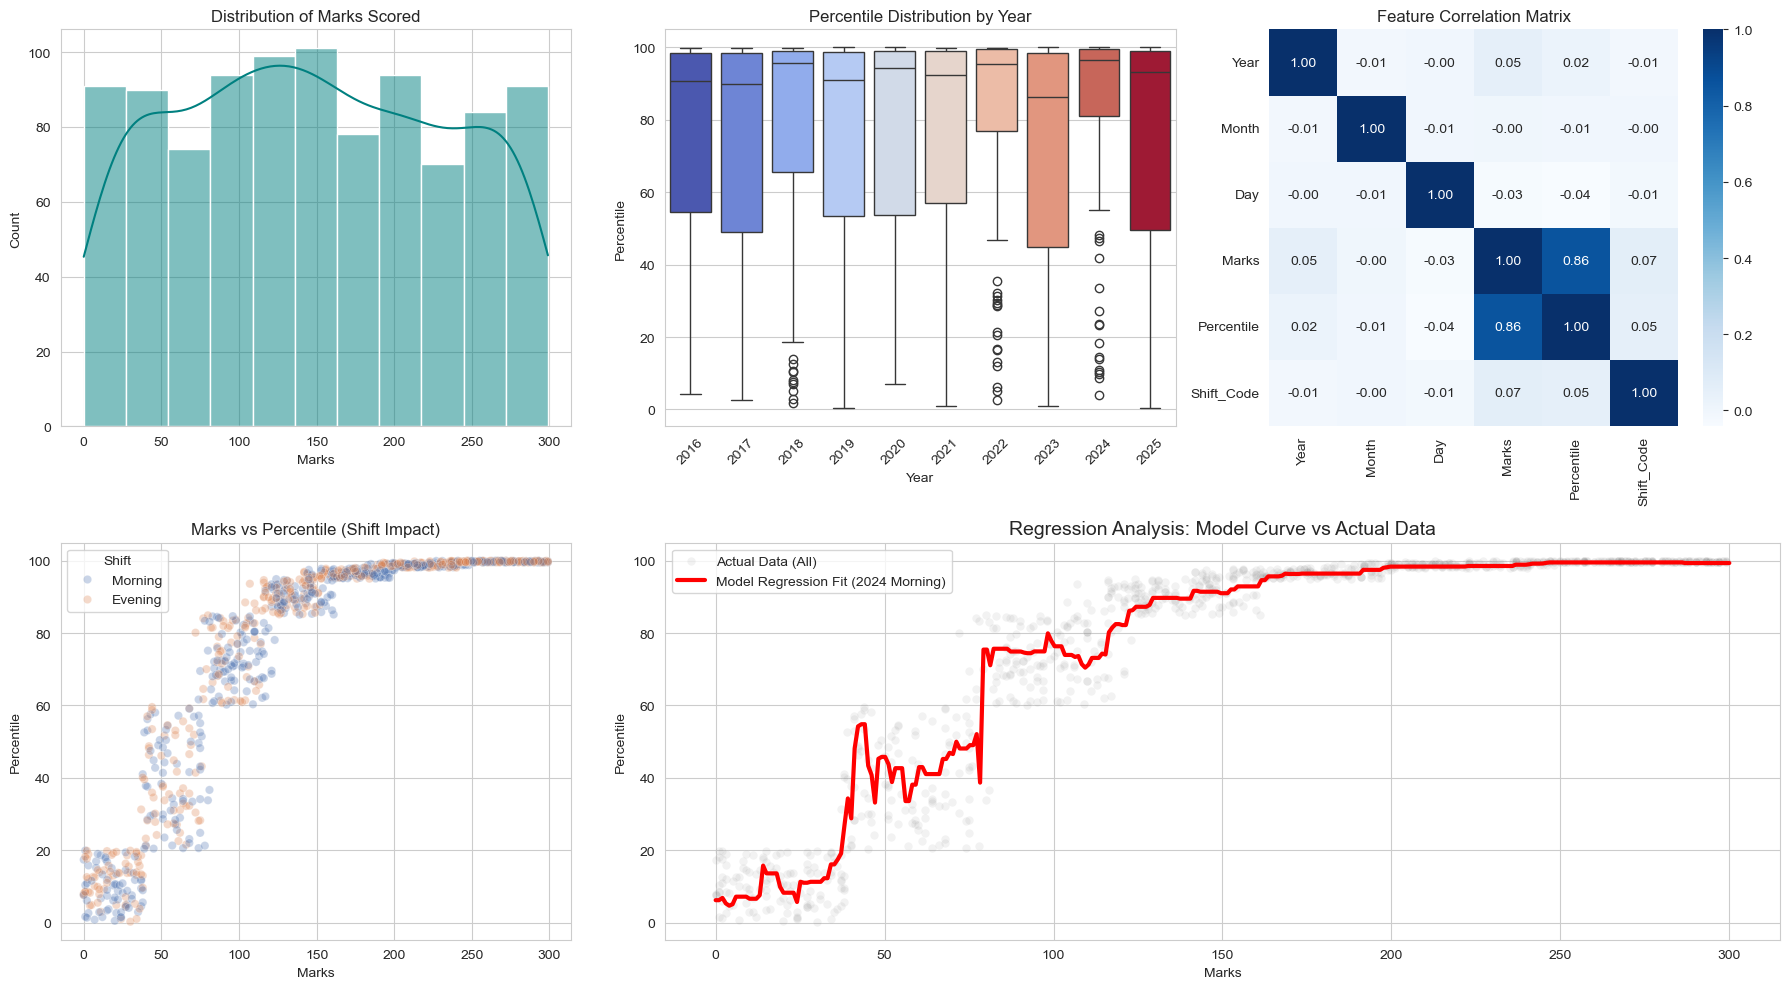


 STEP 5: DYNAMIC PREDICTION INTERFACE

--- Enter Details (or type 'q' to quit) ---


Marks (0-300):  134
Year (e.g., 2024):  2024
Month (1 or 4):  4
Day (1-5):  1
Shift (1 for Morning, 2 for Evening):  2



>>> PREDICTION RESULT <<<
Exam: 2024 | Month: 4 | Day: 1 | Shift: Evening
Score: 134.0
Estimated Percentile: 91.0073
------------------------------

--- Enter Details (or type 'q' to quit) ---


Marks (0-300):  q


In [8]:
#to do 1.data generate 2.data clean 3.model train 4.visualization 5.prediction
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

# Data Generation

def generate_dataset():
    print("\n" + "="*50)
    print(" STEP 1: GENERATING DATASET")
    print("="*50)
    
    np.random.seed(42)
    years = range(2016, 2026)
    shifts = ['Morning', 'Evening']
    months = [1, 4] # Jan, April
    
    rows = []

    def get_percentile(marks, difficulty_factor):
        # Effective marks
        effective_marks = marks * difficulty_factor 
        
        if effective_marks < 0: p = 0
        elif effective_marks < 40: p = np.random.uniform(0, 20)
        elif effective_marks < 80: p = np.random.uniform(20, 60)
        elif effective_marks < 120: p = np.random.uniform(60, 85)
        elif effective_marks < 160: p = np.random.uniform(85, 95)
        elif effective_marks < 200: p = np.random.uniform(95, 98)
        elif effective_marks < 250: p = np.random.uniform(98, 99.5)
        else: p = np.random.uniform(99.5, 99.99)
        
        return min(100, max(0, p))

    for year in years:
        for month in months:
            for day in range(1, 6): # Days 1 to 5
                for shift in shifts:
                   
                    base_diff = 1.0
                    if year in [2018, 2022]: base_diff += 0.1 # Hard years
                    if shift == 'Evening': base_diff += 0.05 # Evening slightly harder
                    
                    for _ in range(5):
                        marks = np.random.randint(0, 300)
                        difficulty = base_diff + np.random.normal(0, 0.02)
                        percentile = get_percentile(marks, difficulty)

                        # Dirty Data
                        if np.random.rand() < 0.01: marks = -50
                        if np.random.rand() < 0.01: marks = "Three Hundred"
                        if np.random.rand() < 0.01: percentile = 105
                        
                        rows.append([year, month, day, shift, marks, percentile])

    df = pd.DataFrame(rows, columns=["Year", "Month", "Day", "Shift", "Marks", "Percentile"])
    
    # Save Raw Data
    df.to_excel("RAW_DATA_ENHANCED.xlsx", index=False)
    print("-> Raw Data Saved to 'RAW_DATA_ENHANCED.xlsx'")
    
    return df

# Cleaning 

def clean_and_explore(df):
    print("\n" + "="*50)
    print(" STEP 2: CLEANING")
    print("="*50)
    
    original_count = len(df)
    
    df["Marks"] = pd.to_numeric(df["Marks"], errors="coerce")
    df["Percentile"] = pd.to_numeric(df["Percentile"], errors="coerce")
    
    df = df.dropna()
    
    # Filter
    df = df[(df["Marks"] >= 0) & (df["Marks"] <= 300)]
    df = df[(df["Percentile"] >= 0) & (df["Percentile"] <= 100)]
    
    # (Morning=0, Evening=1)
    df["Shift_Code"] = df["Shift"].apply(lambda x: 0 if x == 'Morning' else 1)
    
    df.to_excel("CLEANED_DATA_ENHANCED.xlsx", index=False)
    print(f"-> Cleaned Data. Rows: {original_count} -> {len(df)}")
    print("-> Saved to 'CLEANED_DATA_ENHANCED.xlsx'")
    
    return df

# Model Training

def train_model(df):
    print("\n" + "="*50)
    print(" STEP 3: MODEL TRAINING (Gradient Boosting)")
    print("="*50)
    
    X = df[["Marks", "Year", "Month", "Day", "Shift_Code"]]
    y = df["Percentile"]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    
    print(f"-> Model Trained. R^2 Score: {r2:.4f}")
    return model

#Visualization

def visualize_data(df, model):
    print("\n" + "="*50)
    print(" STEP 4: ADVANCED VISUALIZATION")
    print("="*50)
    
    sns.set_style("whitegrid")
    
    fig = plt.figure(figsize=(18, 10))
    gs = fig.add_gridspec(2, 3)

    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    ax3 = fig.add_subplot(gs[0, 2])
    ax4 = fig.add_subplot(gs[1, 0])
    ax5 = fig.add_subplot(gs[1, 1:]) # Spans 2 cols for the Regression Plot

    # Plot 1: Distribution of Marks
    sns.histplot(data=df, x="Marks", kde=True, color="teal", ax=ax1)
    ax1.set_title("Distribution of Marks Scored")
    
    # Plot 2: Percentile Distribution by Year
    sns.boxplot(data=df, x="Year", y="Percentile", hue="Year", palette="coolwarm",legend=False, ax=ax2)
    ax2.set_title("Percentile Distribution by Year")
    ax2.tick_params(axis='x', rotation=45)
    
    # Plot 3: Correlation Matrix
    corr = df[["Year", "Month", "Day", "Marks", "Percentile", "Shift_Code"]].corr()
    sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f", ax=ax3)
    ax3.set_title("Feature Correlation Matrix")
    
    # Plot 4: Marks vs Percentile
    sns.scatterplot(data=df, x="Marks", y="Percentile", hue="Shift", palette="deep", alpha=0.3, ax=ax4)
    ax4.set_title("Marks vs Percentile (Shift Impact)")

    # Plot 5: REGRESSION 
    # ex: 2024 Morning
    X_plot = np.linspace(0, 300, 300).reshape(-1, 1)
    scenario_data = pd.DataFrame(X_plot, columns=["Marks"])
    scenario_data["Year"] = 2024
    scenario_data["Month"] = 1
    scenario_data["Day"] = 1
    scenario_data["Shift_Code"] = 0 # Morning
    
    y_plot = model.predict(scenario_data)

    # Actual Data(bg)
    sns.scatterplot(data=df, x="Marks", y="Percentile", color='gray', alpha=0.1, label='Actual Data (All)', ax=ax5)
    # Regression Curve
    ax5.plot(X_plot, y_plot, color='red', linewidth=3, label='Model Regression Fit (2024 Morning)')
    
    ax5.set_title("Regression Analysis: Model Curve vs Actual Data", fontsize=14)
    ax5.set_xlabel("Marks")
    ax5.set_ylabel("Percentile")
    ax5.legend()
    
    plt.tight_layout()
    plt.show()

# Prediction 

def predict_percentile(model):
    print("\n" + "="*50)
    print(" STEP 5: DYNAMIC PREDICTION INTERFACE")
    print("="*50)
    
    while True:
        try:
            print("\n--- Enter Details (or type 'q' to quit) ---")
            val = input("Marks (0-300): ")
            if val.lower() == 'q': break
            marks = float(val)
            
            year = int(input("Year (e.g., 2024): "))
            month = int(input("Month (1 or 4): "))
            day = int(input("Day (1-5): "))
            shift_input = input("Shift (1 for Morning, 2 for Evening): ")
            
            if not (0 <= marks <= 300):
                print("Error: Marks must be 0-300")
                continue
                
            shift_code = 0 if shift_input == '1' else 1
            shift_name = "Morning" if shift_code == 0 else "Evening"
            
            input_data = pd.DataFrame([[marks, year, month, day, shift_code]], 
                                      columns=["Marks", "Year", "Month", "Day", "Shift_Code"])
            
            pred = model.predict(input_data)[0]
            pred = max(0, min(100, pred))
            
            print(f"\n>>> PREDICTION RESULT <<<")
            print(f"Exam: {year} | Month: {month} | Day: {day} | Shift: {shift_name}")
            print(f"Score: {marks}")
            print(f"Estimated Percentile: {pred:.4f}")
            print("-" * 30)
            
        except ValueError:
            print("Invalid input format.")

# Main

if __name__ == "__main__":
    df_raw = generate_dataset()
    df_clean = clean_and_explore(df_raw)
    gb_model = train_model(df_clean)
    visualize_data(df_clean, gb_model)
    predict_percentile(gb_model)